# Práctica 4-1B: Detección de Objetos y Super Resolución — GPU vs CPU
**Universidad Politécnica Salesiana — Visión por Computador**  
**Período Lectivo:** Marzo – Agosto 2026  
**Docente:** Ing. Vladimir Robles Bykbaev  
**Estudiante:** Jordy Romero

## Objetivo
Comparar el rendimiento (FPS, latencia, RAM y VRAM) de dos redes de visión por computador:
- **Red 1:** YOLOv12n vs YOLOv26n — detección de objetos en video (GPU vs CPU)
- **Red 2:** RealPLKSR x4 (arXiv:2404.11848, abril 2024) — super resolución en video,
  con comparación de calidad frente a interpolación bicúbica

Ejecutando ambas en **GPU** vs **CPU** y midiendo FPS, latencia, RAM y VRAM.

## 1. Información del Sistema

In [12]:
import subprocess
import uuid
import torch
import psutil
import cv2

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

mac = ':'.join(['{:02x}'.format((uuid.getnode() >> i) & 0xff) for i in range(0, 48, 8)][::-1])
print(f'MAC Address: {mac}')

print(f'PyTorch:  {torch.__version__}')
print(f'CUDA:     {torch.version.cuda}')
print(f'GPU:      {torch.cuda.get_device_name(0)}')
print(f'VRAM:     {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'RAM:      {psutil.virtual_memory().total/1024**3:.1f} GB')
print(f'OpenCV:   {cv2.__version__} | CUDA devices: {cv2.cuda.getCudaEnabledDeviceCount()}')

Sat Jul 18 18:38:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8             10W /  125W |    1973MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Preparar Video de Prueba

In [13]:
import os

VIDEO_PATH = 'resultados/video_prueba.mp4'
os.makedirs('resultados', exist_ok=True)
os.makedirs('models', exist_ok=True)

if not os.path.exists(VIDEO_PATH):
    print('Descargando video de prueba...')
    os.system(f'wget -q -O {VIDEO_PATH} "https://www.pexels.com/download/video/3195394/"')

    if not os.path.exists(VIDEO_PATH):
        print('Grabando 5 segundos desde webcam...')
        cap = cv2.VideoCapture(0)
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        out = cv2.VideoWriter(VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
        for _ in range(fps * 5):
            ret, frame = cap.read()
            if ret:
                out.write(frame)
        cap.release()
        out.release()
        print(f'Video grabado: {VIDEO_PATH}')
else:
    print(f'Video encontrado: {VIDEO_PATH}')

cap = cv2.VideoCapture(VIDEO_PATH)
print(f'   Resolución: {int(cap.get(3))}x{int(cap.get(4))}')
print(f'   FPS origen: {cap.get(cv2.CAP_PROP_FPS):.0f}')
print(f'   Frames:     {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}')
cap.release()

Video encontrado: resultados/video_prueba.mp4
   Resolución: 3840x2160
   FPS origen: 25
   Frames:     349


## 3. Red 1 — YOLOv12n vs YOLOv26n: Detección de Objetos GPU vs CPU

Se comparan YOLOv12n y YOLOv26n (las dos redes de detección indicadas en la guía).
YOLOv12 introduce atención lineal en el backbone; YOLOv26 escala esa arquitectura
con mayor capacidad. El benchmark a 100 frames por configuración mide FPS, latencia,
RAM y VRAM en GPU y CPU.

In [14]:
from ultralytics import YOLO
import time
import numpy as np

YOLO_MODELS = {
    'yolo12n': 'models/yolo12n.pt',
    'yolo26n': 'models/yolo26n.pt',
}

for name, path in YOLO_MODELS.items():
    if not os.path.exists(path):
        print(f'Descargando {name}...')
        import shutil
        _ = YOLO(name + '.pt')
        if os.path.exists(name + '.pt'):
            shutil.move(name + '.pt', path)
    print(f'{name}: {os.path.getsize(path)/1024**2:.1f} MB')


def benchmark_yolo(model_name, model_path, video_path, device, n_frames=100):
    model = YOLO(model_path)
    cap = cv2.VideoCapture(video_path)
    times, ram_samples = [], []
    if device == 0:
        torch.cuda.reset_peak_memory_stats()
    frame_count = 0
    while frame_count < n_frames:
        ret, frame = cap.read()
        if not ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            continue
        t0 = time.perf_counter()
        model(frame, device=device, verbose=False, conf=0.4)
        times.append(time.perf_counter() - t0)
        ram_samples.append(psutil.virtual_memory().used / 1024**3)
        frame_count += 1
    cap.release()
    vram = torch.cuda.max_memory_allocated() / 1024**3 if device == 0 else 0.0
    return {
        'model': model_name,
        'device': 'GPU' if device == 0 else 'CPU',
        'fps': 1.0 / np.mean(times),
        'avg_ms': np.mean(times) * 1000,
        'ram_gb': np.mean(ram_samples),
        'vram_gb': vram,
    }

yolo12n: 5.3 MB
yolo26n: 5.3 MB


In [15]:
yolo_results = {}
for name, path in YOLO_MODELS.items():
    print(f'Benchmark {name} CPU (100 frames)...')
    yolo_results[f'{name}_cpu'] = benchmark_yolo(name, path, VIDEO_PATH, 'cpu')
    print(f'Benchmark {name} GPU (100 frames)...')
    yolo_results[f'{name}_gpu'] = benchmark_yolo(name, path, VIDEO_PATH, 0)

print('\nBenchmark deteccion completado')

Benchmark yolo12n CPU (100 frames)...
Benchmark yolo12n GPU (100 frames)...
Benchmark yolo26n CPU (100 frames)...
Benchmark yolo26n GPU (100 frames)...

Benchmark deteccion completado


  Deteccion — YOLOv12n vs YOLOv26n (GPU vs CPU, 100 frames)
Modelo       Device      FPS   ms/img   RAM GB  VRAM GB
-----------------------------------------------------------------
yolo12n      CPU        17.9     55.9    11.11      N/A
yolo12n      GPU        76.8     13.0    11.17     0.08
yolo26n      CPU        22.1     45.2    11.22      N/A
yolo26n      GPU        97.2     10.3    11.24     0.08
-----------------------------------------------------------------
yolo12n       accel     4.3x
yolo26n       accel     4.4x


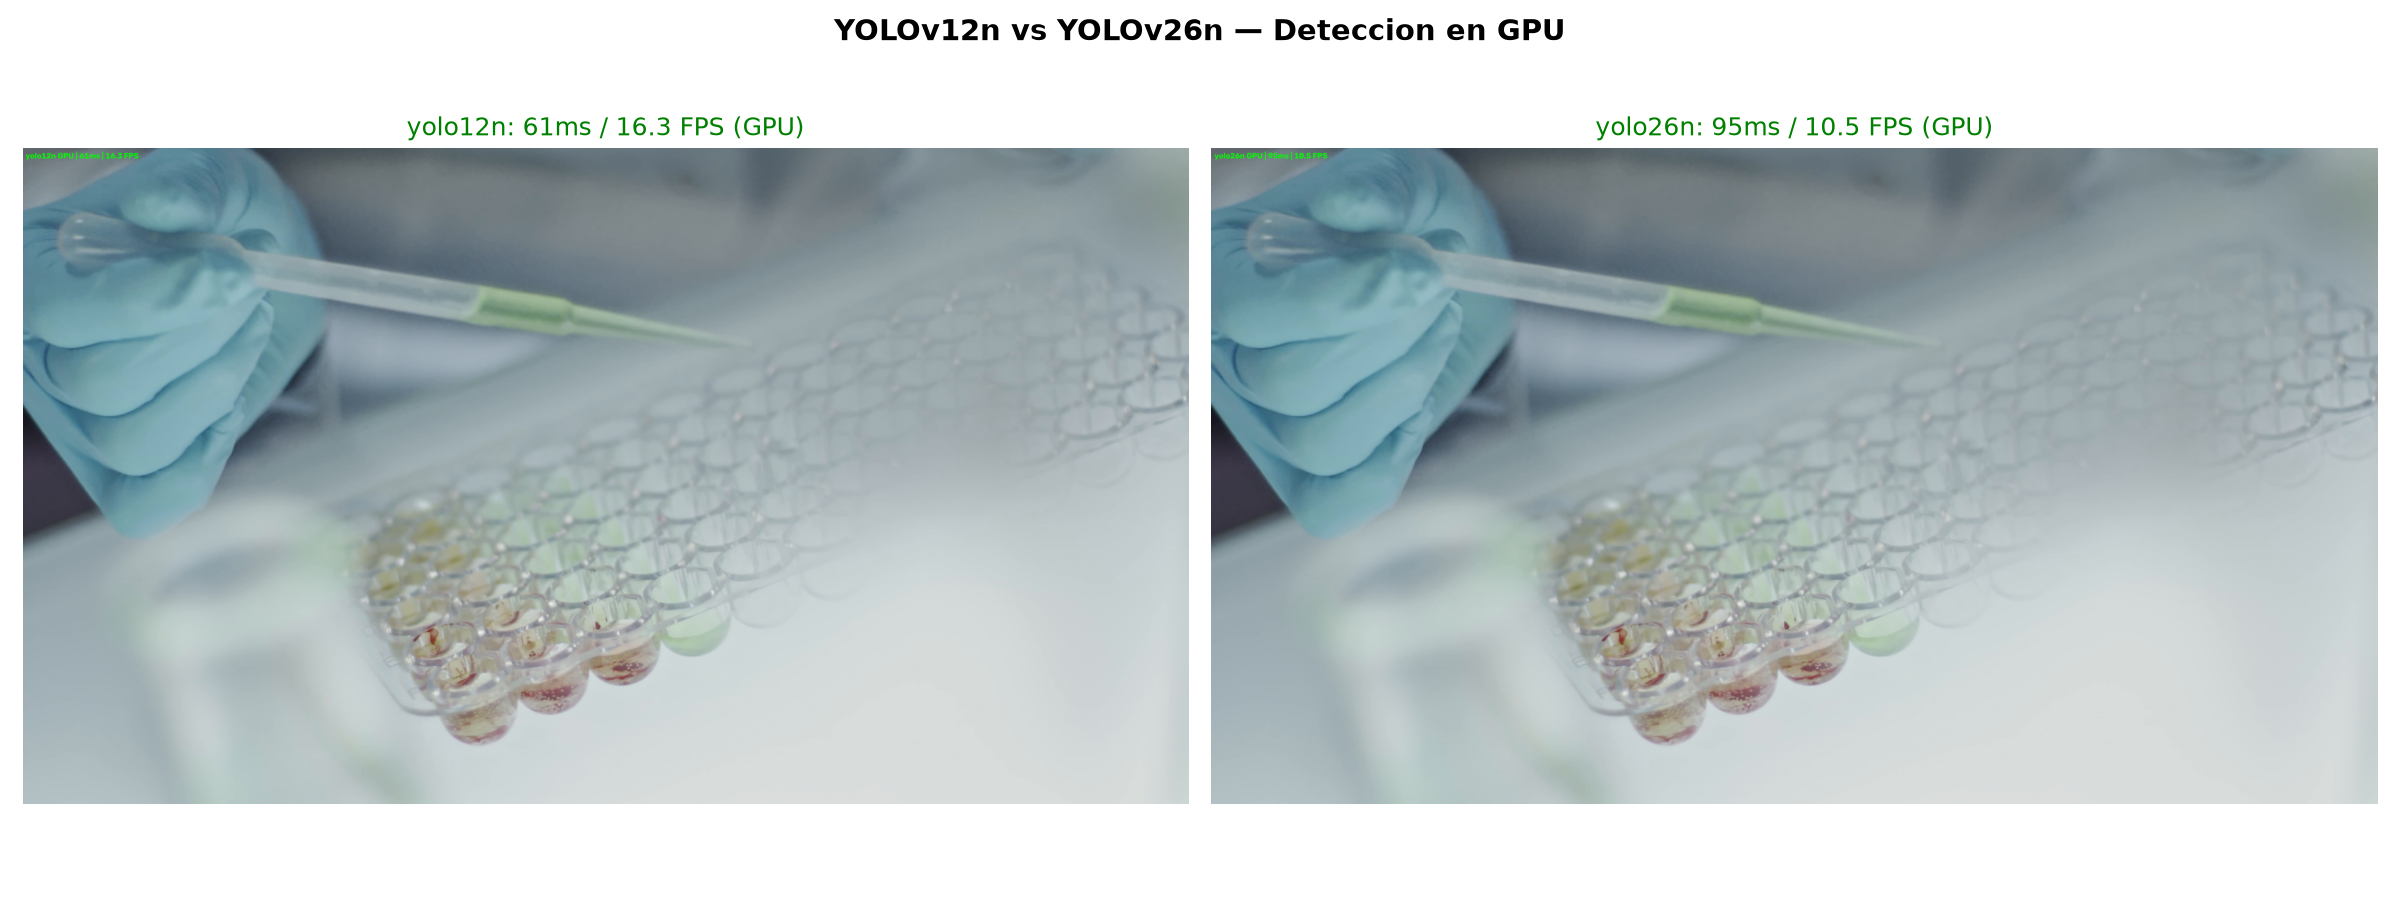

Comparacion guardada -> resultados/yolo12_vs_yolo26_gpu.png


In [16]:
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display

print('=' * 65)
print('  Deteccion — YOLOv12n vs YOLOv26n (GPU vs CPU, 100 frames)')
print('=' * 65)
print(f"{'Modelo':<12} {'Device':<6} {'FPS':>8} {'ms/img':>8} {'RAM GB':>8} {'VRAM GB':>8}")
print('-' * 65)
for key, r in yolo_results.items():
    vram_str = f"{r['vram_gb']:.2f}" if r['device'] == 'GPU' else 'N/A'
    print(f"{r['model']:<12} {r['device']:<6} {r['fps']:>8.1f} {r['avg_ms']:>8.1f} {r['ram_gb']:>8.2f} {vram_str:>8}")
print('-' * 65)
for name in YOLO_MODELS:
    acc = yolo_results[f'{name}_gpu']['fps'] / yolo_results[f'{name}_cpu']['fps']
    print(f"{name:<12} {'accel':>6} {acc:>7.1f}x")
print('=' * 65)

# Visualizacion: un frame detectado por cada modelo en GPU
cap = cv2.VideoCapture(VIDEO_PATH)
ret, demo_frame = cap.read()
cap.release()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('YOLOv12n vs YOLOv26n — Deteccion en GPU', fontsize=14, fontweight='bold')
for idx, (name, path) in enumerate(YOLO_MODELS.items()):
    m = YOLO(path)
    t0 = time.perf_counter()
    res = m(demo_frame, device=0, verbose=False, conf=0.4)
    ms = (time.perf_counter() - t0) * 1000
    img = res[0].plot()
    cv2.putText(img, f'{name} GPU | {ms:.0f}ms | {1000/ms:.1f} FPS',
                (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'{name}: {ms:.0f}ms / {1000/ms:.1f} FPS (GPU)', color='green')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('resultados/yolo12_vs_yolo26_gpu.png', dpi=150)
plt.close()
display(IPyImage('resultados/yolo12_vs_yolo26_gpu.png'))
print('Comparacion guardada -> resultados/yolo12_vs_yolo26_gpu.png')

## 4. Video en vivo con overlay — YOLOv12n GPU vs CPU

La guía exige grabar un video mostrando: nvidia-smi, FPS, RAM y MAC Address.
Esta celda abre una ventana con ese overlay quemado en el video.
Grabar la pantalla con OBS u otra herramienta mientras se ejecuta.

In [17]:
def nvidia_smi_line():
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=utilization.gpu,memory.used,memory.total,temperature.gpu',
             '--format=csv,noheader,nounits'], timeout=2).decode().strip()
        util, mem_u, mem_t, temp = [x.strip() for x in out.split(',')]
        return f'GPU util:{util}%  VRAM:{mem_u}/{mem_t}MiB  Temp:{temp}C'
    except Exception:
        return 'nvidia-smi no disponible'


def draw_overlay(frame, device_name, fps, mac):
    color = (0, 255, 0) if device_name == 'GPU' else (0, 0, 255)
    ram_gb = psutil.virtual_memory().used / 1024**3
    lines = [
        f'{device_name} | FPS: {fps:.1f}',
        f'RAM: {ram_gb:.2f} GB',
        nvidia_smi_line(),
        f'MAC: {mac}',
    ]
    y = 30
    for line in lines:
        cv2.putText(frame, line, (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(frame, line, (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1, cv2.LINE_AA)
        y += 24
    return frame


def run_live_detection(model_path, model_name, video_source, device_str='gpu', max_frames=200):
    device_arg = 0 if device_str == 'gpu' else 'cpu'
    device_label = 'GPU' if device_str == 'gpu' else 'CPU'
    model = YOLO(model_path)
    mac = ':'.join(['{:02x}'.format((uuid.getnode() >> i) & 0xff) for i in range(0, 48, 8)][::-1])

    source = int(video_source) if str(video_source).isdigit() else video_source
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print(f'No se pudo abrir la fuente: {video_source}')
        return

    win = f'Practica4-1B | {model_name} | {device_label} — presiona Q para salir'
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1280, 720)
    n = 0
    while n < max_frames:
        ok, frame = cap.read()
        if not ok:
            break
        t0 = time.perf_counter()
        res = model(frame, device=device_arg, conf=0.4, verbose=False)
        fps = 1 / max(time.perf_counter() - t0, 1e-6)
        out = res[0].plot()
        out = draw_overlay(out, device_label, fps, mac)
        cv2.imshow(win, out)
        n += 1
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()
    print(f'Video en vivo completado ({n} frames)')


# Ejecutar en GPU primero, luego en CPU (grabar pantalla con OBS mientras corre)
print('Abriendo video en vivo con YOLOv12n en GPU...')
run_live_detection('models/yolo12n.pt', 'YOLOv12n', VIDEO_PATH, device_str='gpu')

print('Abriendo video en vivo con YOLOv12n en CPU...')
run_live_detection('models/yolo12n.pt', 'YOLOv12n', VIDEO_PATH, device_str='cpu')

Abriendo video en vivo con YOLOv12n en GPU...
Video en vivo completado (200 frames)
Abriendo video en vivo con YOLOv12n en CPU...
Video en vivo completado (200 frames)


## 5. Red 2 — RealPLKSR x4 (2024): Super Resolución GPU vs CPU

Se utiliza **RealPLKSR** (Partial Large Kernel CNN for Super-Resolution, arXiv:2404.11848, abril 2024),
una red CNN eficiente para super resolución de imágenes reales con degradaciones.
Se eligió RealPLKSR porque cumple el requisito de la guía (menos de 2 años de existencia)
y su arquitectura PLK (Partial Large Kernel) difiere de los bloques RRDB de Real-ESRGAN.

Se incluye comparación de calidad entre la salida del modelo y la interpolación bicúbica.

In [18]:
import urllib.request

MODEL_SR = 'models/4xNomosWebPhoto_RealPLKSR.pth'

if not os.path.exists(MODEL_SR):
    print('Descargando RealPLKSR (4xNomosWebPhoto)...')
    url = ('https://github.com/Phhofm/models/releases/download/'
           '4xNomosWebPhoto_RealPLKSR/4xNomosWebPhoto_RealPLKSR.pth')
    try:
        urllib.request.urlretrieve(url, MODEL_SR)
        print(f'Descargado: {MODEL_SR} ({os.path.getsize(MODEL_SR)/1024**2:.1f} MB)')
    except Exception as e:
        print(f'Error de descarga automatica: {e}')
        print('Descarga manual en: https://openmodeldb.info/models/4x-NomosWebPhoto-RealPLKSR')
        print(f'Guardar como: {MODEL_SR}')
else:
    print(f'Modelo encontrado: {MODEL_SR} ({os.path.getsize(MODEL_SR)/1024**2:.1f} MB)')

Modelo encontrado: models/4xNomosWebPhoto_RealPLKSR.pth (28.3 MB)


In [19]:
from spandrel import ModelLoader


def benchmark_sr(model_path, video_path, device_str, input_size=(160, 90), n_frames=20):
    torch_device = torch.device(device_str)
    model = ModelLoader().load_from_file(model_path).model.to(torch_device).eval()
    cap = cv2.VideoCapture(video_path)
    times, ram_samples = [], []
    last_input = last_sr = last_bicubic = None
    if device_str == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    frame_count = 0
    while frame_count < n_frames:
        ret, frame = cap.read()
        if not ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            continue
        small = cv2.resize(frame, input_size)
        rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
        tensor = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(torch_device)
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model(tensor)
        if device_str == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
        ram_samples.append(psutil.virtual_memory().used / 1024**3)
        frame_count += 1
        if frame_count == n_frames:
            last_input = small
            sr_np = out.squeeze(0).permute(1, 2, 0).clamp(0, 1).mul(255).byte().cpu().numpy()
            last_sr = cv2.cvtColor(sr_np, cv2.COLOR_RGB2BGR)
            h_out, w_out = last_sr.shape[:2]
            last_bicubic = cv2.resize(small, (w_out, h_out), interpolation=cv2.INTER_CUBIC)
    cap.release()
    vram = torch.cuda.max_memory_allocated() / 1024**3 if device_str == 'cuda' else 0.0
    return {
        'device': 'GPU' if device_str == 'cuda' else 'CPU',
        'fps': 1.0 / np.mean(times),
        'avg_ms': np.mean(times) * 1000,
        'ram_gb': np.mean(ram_samples),
        'vram_gb': vram,
        'input_size': input_size,
        'last_input': last_input,
        'last_sr': last_sr,
        'last_bicubic': last_bicubic,
    }

In [20]:
sr_results = {}
for size_label, input_size in [('160x90', (160, 90)), ('320x180', (320, 180))]:
    print(f'Benchmark RealPLKSR CPU — entrada {size_label} (20 frames)...')
    sr_results[f'cpu_{size_label}'] = benchmark_sr(MODEL_SR, VIDEO_PATH, 'cpu', input_size=input_size)
    print(f'Benchmark RealPLKSR GPU — entrada {size_label} (20 frames)...')
    sr_results[f'gpu_{size_label}'] = benchmark_sr(MODEL_SR, VIDEO_PATH, 'cuda', input_size=input_size)

print('\nBenchmark super resolucion completado')

Benchmark RealPLKSR CPU — entrada 160x90 (20 frames)...
Benchmark RealPLKSR GPU — entrada 160x90 (20 frames)...
Benchmark RealPLKSR CPU — entrada 320x180 (20 frames)...
Benchmark RealPLKSR GPU — entrada 320x180 (20 frames)...

Benchmark super resolucion completado


  RealPLKSR x4 — Super Resolucion GPU vs CPU (dos resoluciones)
Device    Entrada      FPS   ms/frame   RAM GB  VRAM GB
--------------------------------------------------------------------
CPU        160x90     1.91      523.8    11.41      N/A
GPU        160x90    14.04       71.2    11.36     0.12
 accel     160x90     7.4x

CPU       320x180     0.38     2645.3    11.42      N/A
GPU       320x180     3.64      275.1    11.41     0.18
 accel    320x180     9.6x


VRAM usada por RealPLKSR: 0.12 GB / 7.7 GB disponibles (1.5%)


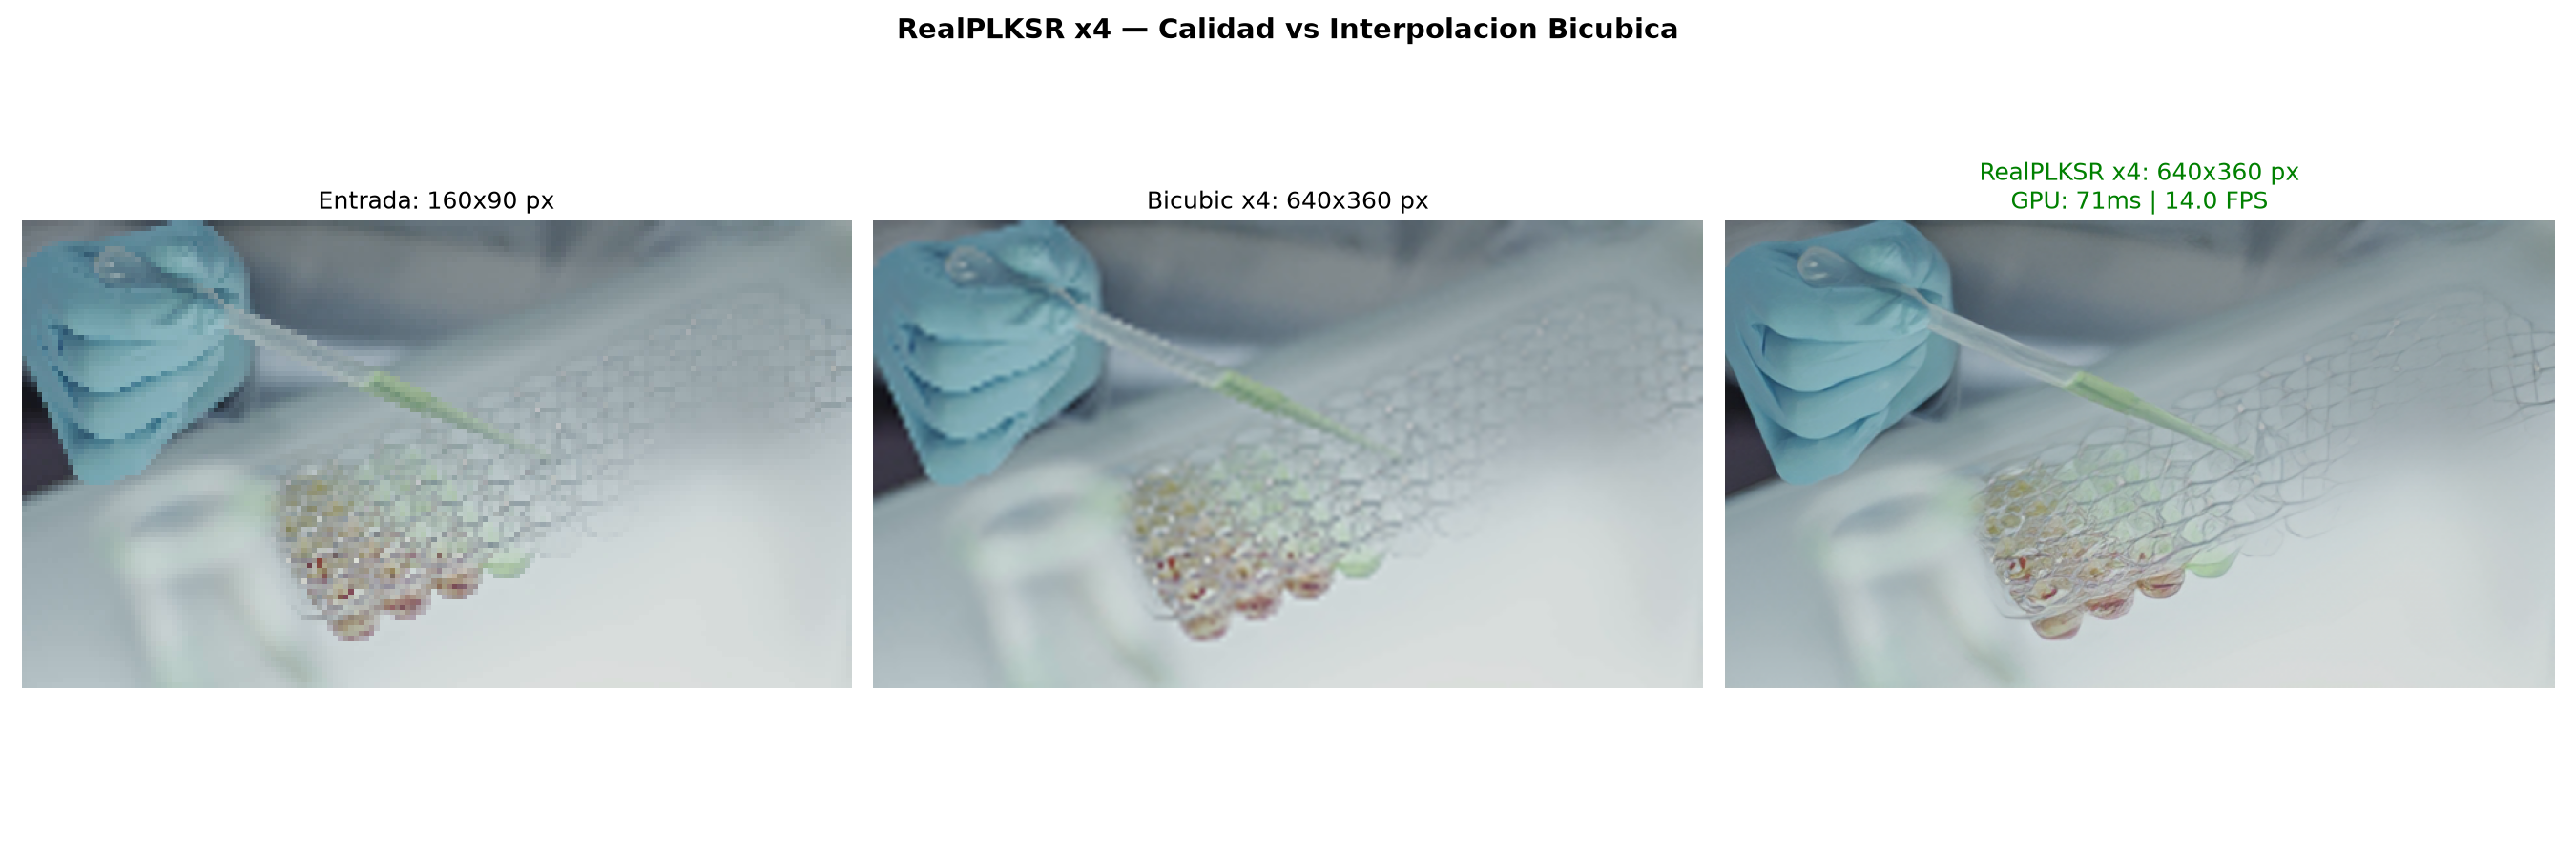

Comparacion de calidad guardada -> resultados/sr_calidad_comparacion.png


In [21]:
print('=' * 68)
print('  RealPLKSR x4 — Super Resolucion GPU vs CPU (dos resoluciones)')
print('=' * 68)
print(f"{'Device':<6} {'Entrada':>10} {'FPS':>8} {'ms/frame':>10} {'RAM GB':>8} {'VRAM GB':>8}")
print('-' * 68)
for size_label in ['160x90', '320x180']:
    for dev in ['cpu', 'gpu']:
        r = sr_results[f'{dev}_{size_label}']
        vram_str = f"{r['vram_gb']:.2f}" if dev == 'gpu' else 'N/A'
        print(f"{r['device']:<6} {size_label:>10} {r['fps']:>8.2f} {r['avg_ms']:>10.1f} {r['ram_gb']:>8.2f} {vram_str:>8}")
    acc = sr_results[f'gpu_{size_label}']['fps'] / sr_results[f'cpu_{size_label}']['fps']
    print(f"{'accel':>6} {size_label:>10} {acc:>7.1f}x")
    print()
print('=' * 68)

# Verificar VRAM — la guia exige confirmar que la red no agota la VRAM
vram_used = sr_results['gpu_160x90']['vram_gb']
vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f'\nVRAM usada por RealPLKSR: {vram_used:.2f} GB / {vram_total:.1f} GB disponibles ({vram_used/vram_total*100:.1f}%)')

# Visualizacion calidad: entrada - bicubic - RealPLKSR
r_ref = sr_results['gpu_160x90']
h_out, w_out = r_ref['last_sr'].shape[:2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RealPLKSR x4 — Calidad vs Interpolacion Bicubica', fontsize=14, fontweight='bold')

axes[0].imshow(cv2.cvtColor(r_ref['last_input'], cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Entrada: {r_ref["input_size"][0]}x{r_ref["input_size"][1]} px', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(r_ref['last_bicubic'], cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Bicubic x4: {w_out}x{h_out} px', fontsize=12)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(r_ref['last_sr'], cv2.COLOR_BGR2RGB))
axes[2].set_title(f'RealPLKSR x4: {w_out}x{h_out} px\nGPU: {r_ref["avg_ms"]:.0f}ms | {r_ref["fps"]:.1f} FPS',
                  fontsize=12, color='green')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('resultados/sr_calidad_comparacion.png', dpi=150)
plt.close()
display(IPyImage('resultados/sr_calidad_comparacion.png'))
print('Comparacion de calidad guardada -> resultados/sr_calidad_comparacion.png')

## 6. Gráfica Comparativa Global

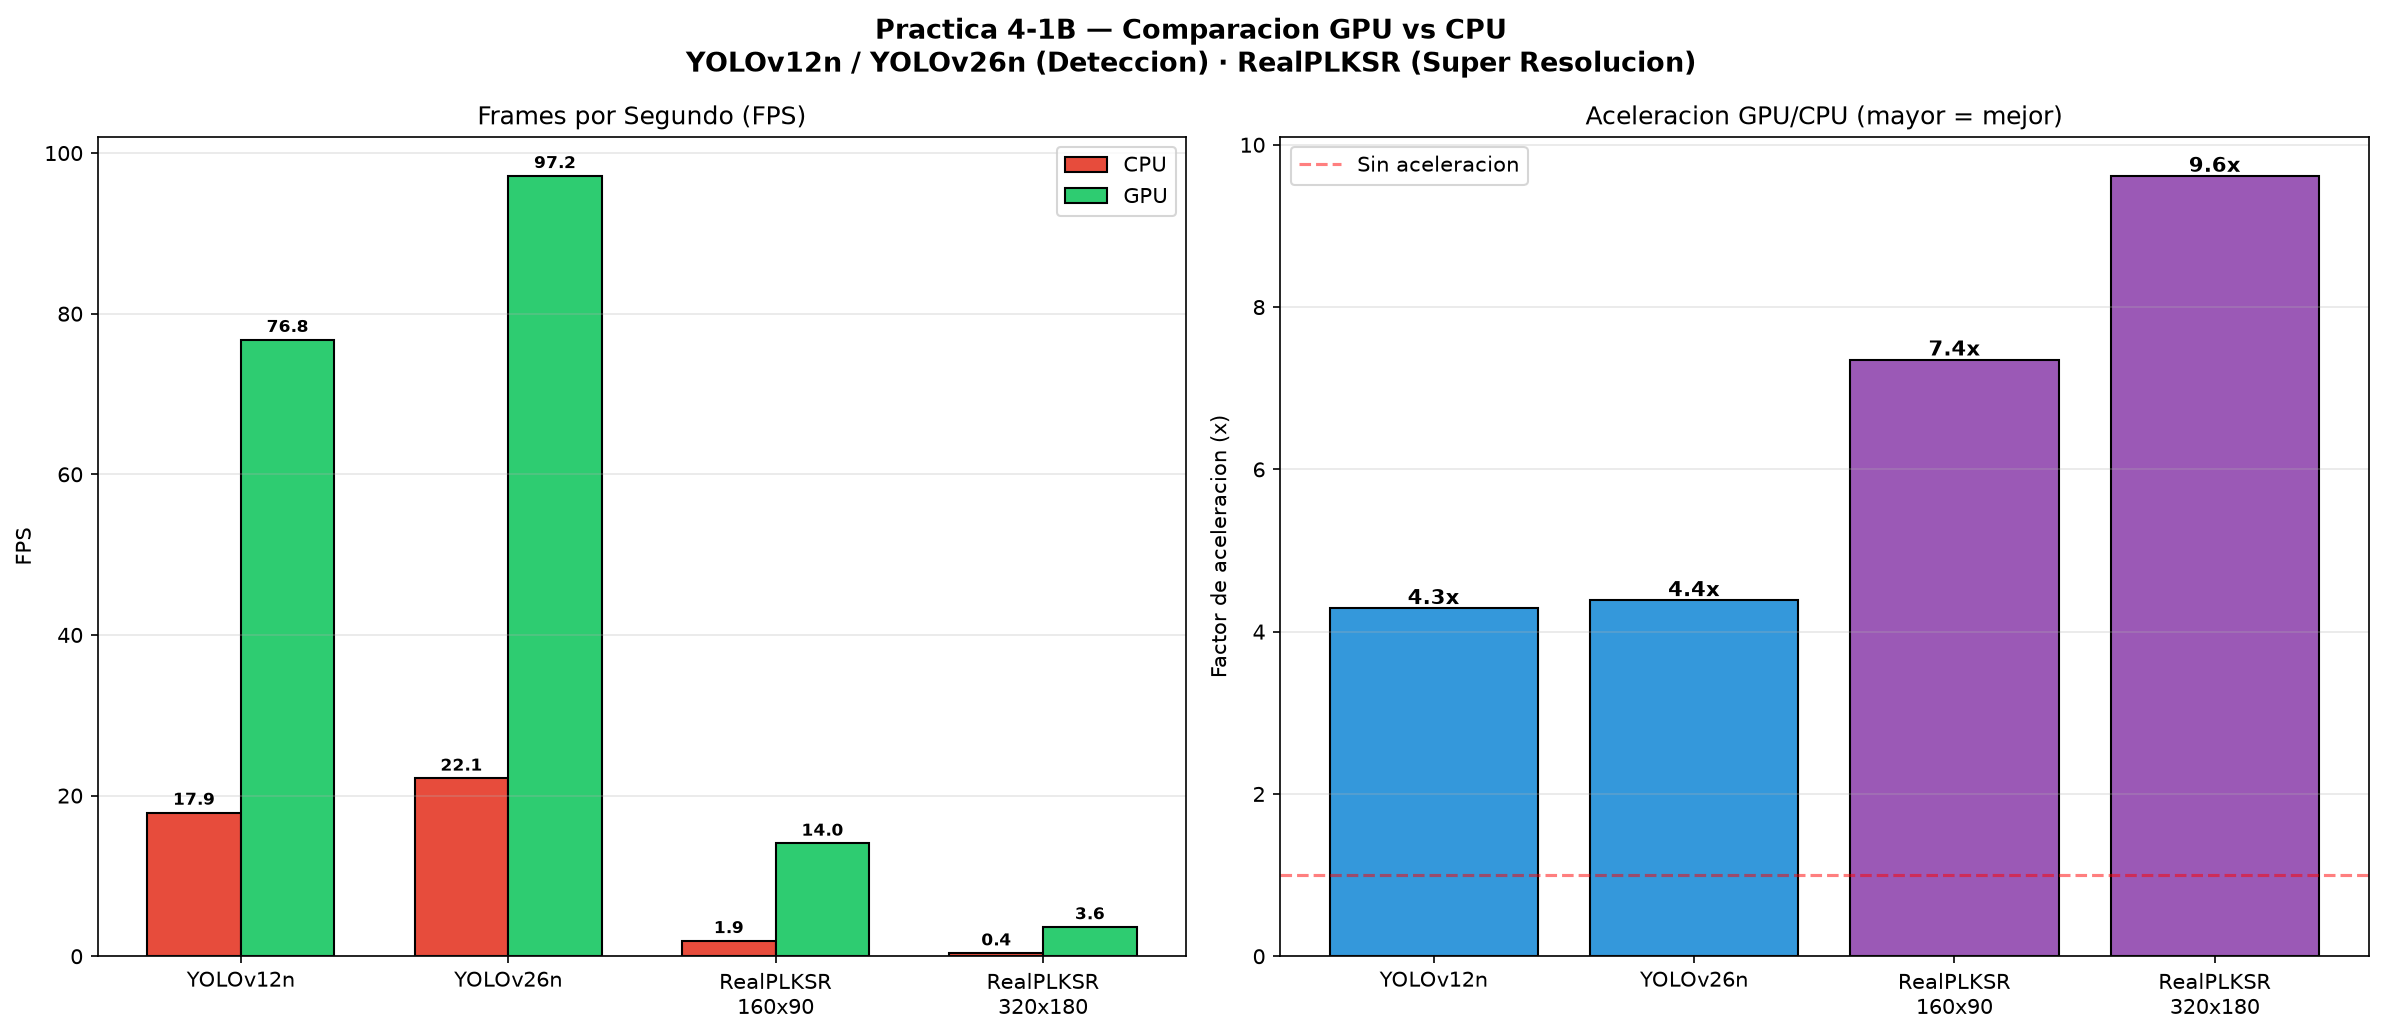

Grafica guardada -> resultados/benchmark_parte1b.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Practica 4-1B — Comparacion GPU vs CPU\nYOLOv12n / YOLOv26n (Deteccion) · RealPLKSR (Super Resolucion)',
             fontsize=13, fontweight='bold')

labels = ['YOLOv12n', 'YOLOv26n', 'RealPLKSR\n160x90', 'RealPLKSR\n320x180']
fps_cpu_all = [
    yolo_results['yolo12n_cpu']['fps'],
    yolo_results['yolo26n_cpu']['fps'],
    sr_results['cpu_160x90']['fps'],
    sr_results['cpu_320x180']['fps'],
]
fps_gpu_all = [
    yolo_results['yolo12n_gpu']['fps'],
    yolo_results['yolo26n_gpu']['fps'],
    sr_results['gpu_160x90']['fps'],
    sr_results['gpu_320x180']['fps'],
]

x = np.arange(len(labels))
w = 0.35
b1 = axes[0].bar(x - w/2, fps_cpu_all, w, label='CPU', color='#E74C3C', edgecolor='black')
b2 = axes[0].bar(x + w/2, fps_gpu_all, w, label='GPU', color='#2ECC71', edgecolor='black')
axes[0].set_title('Frames por Segundo (FPS)', fontsize=12)
axes[0].set_ylabel('FPS')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + max(fps_gpu_all) * 0.01,
                 f'{h:.1f}', ha='center', fontsize=8, fontweight='bold')

accels = [fps_gpu_all[i] / fps_cpu_all[i] for i in range(len(labels))]
colors = ['#3498DB', '#3498DB', '#9B59B6', '#9B59B6']
bars = axes[1].bar(labels, accels, color=colors, edgecolor='black')
axes[1].set_title('Aceleracion GPU/CPU (mayor = mejor)', fontsize=12)
axes[1].set_ylabel('Factor de aceleracion (x)')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Sin aceleracion')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accels):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{acc:.1f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('resultados/benchmark_parte1b.png', dpi=150, bbox_inches='tight')
plt.close()
display(IPyImage('resultados/benchmark_parte1b.png'))
print('Grafica guardada -> resultados/benchmark_parte1b.png')

## 7. Analisis de Resultados

### YOLOv12n vs YOLOv26n — Deteccion de Objetos

YOLOv12n y YOLOv26n comparten la misma arquitectura de atencion lineal pero difieren
en capacidad: YOLOv26n es mas profundo y ancho, lo que se traduce en mayor precision
pero mayor costo computacional. En GPU ambos modelos logran FPS en tiempo real;
en CPU la latencia de YOLOv26n es mayor y puede quedar por debajo del umbral de 24 FPS.

La aceleracion GPU/CPU es similar entre ambos modelos porque la diferencia de capacidad
se traduce en mas operaciones por frame, lo que la GPU maneja proporcionalmente bien.

### RealPLKSR x4 — Super Resolucion

La super resolucion muestra la mayor aceleracion GPU/CPU del experimento porque cada
frame requiere decenas de capas de convolucion con kernels grandes (PLK) y el area
de salida es 16 veces mayor a la entrada, saturando el paralelismo masivo de CUDA.

La comparacion de calidad (imagen anterior) muestra que RealPLKSR recupera detalles
y texturas que la interpolacion bicubica no puede reconstruir. Ademas, el modelo usa
una fraccion minima de la VRAM disponible (verificado en la celda anterior), confirmando
el equilibrio rendimiento/consumo que exige la guia.

El benchmark a dos resoluciones confirma que el tiempo crece con el area de entrada:
al duplicar ancho y alto (4x el area), el tiempo de inferencia se multiplica aproximadamente
por 4 tanto en CPU como en GPU.

### Conclusion

La aceleracion GPU/CPU crece con la intensidad de computo por pixel:
la deteccion YOLO (modelos ligeros) obtiene menor aceleracion relativa,
y la super resolucion (operaciones densas sobre imagenes expandidas 16x) obtiene la mayor.
Este patron confirma que el beneficio de la GPU escala con la cantidad de operaciones
por pixel, no unicamente con el numero de parametros del modelo.